In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
from google.colab import files
from skimage.io import imread
from skimage.color import rgb2gray

uploaded = files.upload()

imagens = []

for nome_arquivo in uploaded.keys():
    img = imread(nome_arquivo)

    if len(img.shape) == 3:
        img = rgb2gray(img)

    imagens.append(img)

print(f"{len(imagens)} imagens carregadas")

Saving sandalia1_2.jpg to sandalia1_2.jpg
Saving sandalia1_1.jpg to sandalia1_1.jpg
Saving tenis2_3.jpg to tenis2_3.jpg
Saving tenis2_2.jpg to tenis2_2.jpg
Saving tenis2_1.jpg to tenis2_1.jpg
Saving tenis1_3.jpg to tenis1_3.jpg
Saving tenis1_2.jpg to tenis1_2.jpg
Saving tenis1_1.jpg to tenis1_1.jpg
Saving sandalia2_3.jpg to sandalia2_3.jpg
Saving sandalia2_1.jpg to sandalia2_1.jpg
Saving sandalia2_2.jpg to sandalia2_2.jpg
Saving sandalia1_3.jpg to sandalia1_3.jpg
12 imagens carregadas


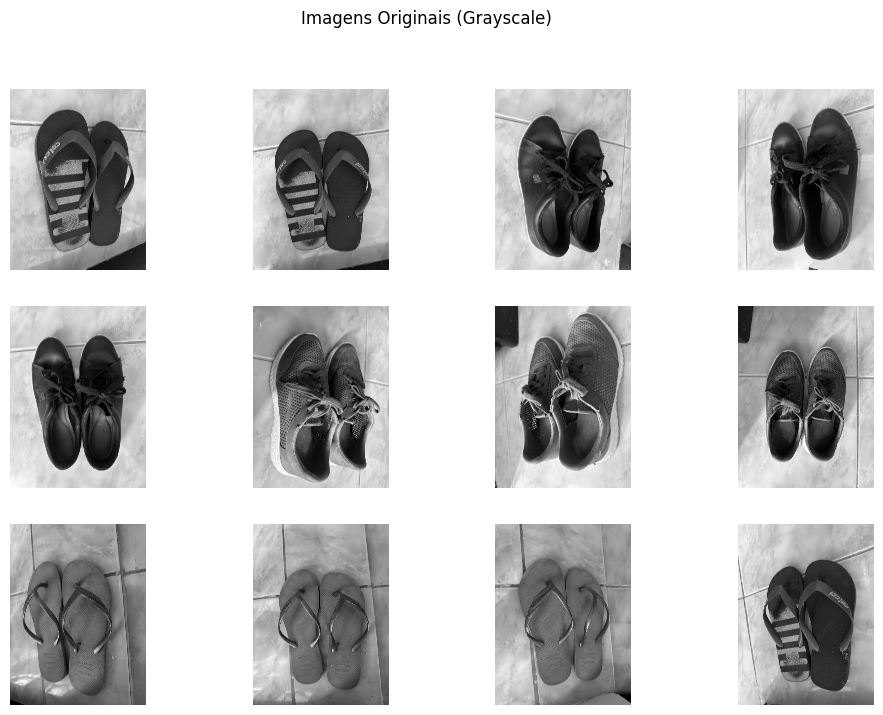

In [4]:
plt.figure(figsize=(12,8))

for i, img in enumerate(imagens):
    plt.subplot(3, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.suptitle("Imagens Originais (Grayscale)")
plt.show()

In [6]:
from skimage.transform import resize
imagens_64 = []

for img in imagens:
    img_resized = resize(img, (64,64), anti_aliasing=True)
    imagens_64.append(img_resized)

print("Dimensão após resize:", imagens_64[0].shape)

Dimensão após resize: (64, 64)


In [15]:
from skimage import feature

imagens_canny = []

for img in imagens_64:
    edges = feature.canny(img, sigma=1)
    imagens_canny.append(edges.astype(float))

print("Exemplo shape:", imagens_canny[0].shape)


Exemplo shape: (64, 64)


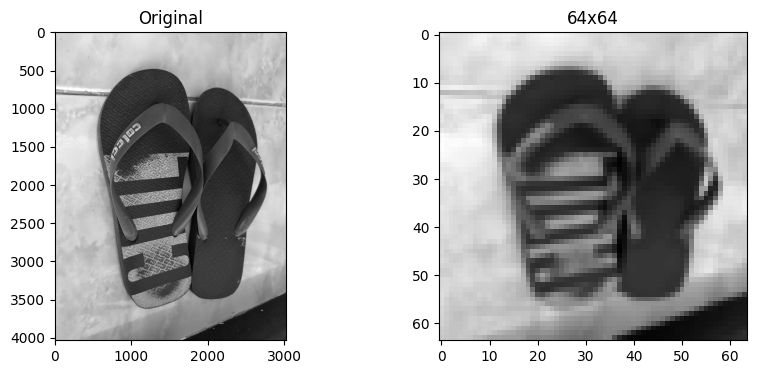

In [7]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(imagens[0], cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(imagens_64[0], cmap='gray')
plt.title("64x64")

plt.show()

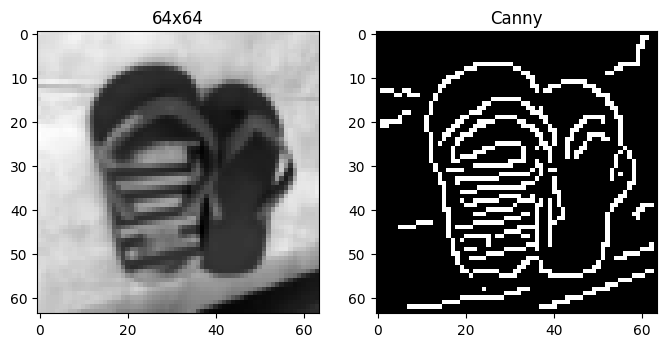

In [16]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagens_64[0], cmap='gray')
plt.title("64x64")

plt.subplot(1,2,2)
plt.imshow(imagens_canny[0], cmap='gray')
plt.title("Canny")

plt.show()


In [26]:
X = []

for img in imagens_64:
    tensor_img = torch.tensor(img, dtype=torch.float32)
    tensor_img = tensor_img.unsqueeze(0)
    X.append(tensor_img)

X = torch.stack(X)


In [27]:
X = X.float()

In [28]:
X = (X - X.min()) / (X.max() - X.min())

In [29]:
y = torch.tensor([1]*6 + [0]*6)


In [30]:
# treino/teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
loss_history = []

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 1/50 - Loss: 0.7066
Epoch 2/50 - Loss: 0.1147
Epoch 3/50 - Loss: 0.3059
Epoch 4/50 - Loss: 0.3150
Epoch 5/50 - Loss: 0.1815
Epoch 6/50 - Loss: 0.1257
Epoch 7/50 - Loss: 0.1478
Epoch 8/50 - Loss: 0.1824
Epoch 9/50 - Loss: 0.1811
Epoch 10/50 - Loss: 0.1461
Epoch 11/50 - Loss: 0.1025
Epoch 12/50 - Loss: 0.0705
Epoch 13/50 - Loss: 0.0579
Epoch 14/50 - Loss: 0.0570
Epoch 15/50 - Loss: 0.0549
Epoch 16/50 - Loss: 0.0476
Epoch 17/50 - Loss: 0.0394
Epoch 18/50 - Loss: 0.0353
Epoch 19/50 - Loss: 0.0354
Epoch 20/50 - Loss: 0.0364
Epoch 21/50 - Loss: 0.0353
Epoch 22/50 - Loss: 0.0315
Epoch 23/50 - Loss: 0.0270
Epoch 24/50 - Loss: 0.0242
Epoch 25/50 - Loss: 0.0235
Epoch 26/50 - Loss: 0.0236
Epoch 27/50 - Loss: 0.0225
Epoch 28/50 - Loss: 0.0200
Epoch 29/50 - Loss: 0.0173
Epoch 30/50 - Loss: 0.0154
Epoch 31/50 - Loss: 0.0145
Epoch 32/50 - Loss: 0.0140
Epoch 33/50 - Loss: 0.0132
Epoch 34/50 - Loss: 0.0120
Epoch 35/50 - Loss: 0.0105
Epoch 36/50 - Loss: 0.0092
Epoch 37/50 - Loss: 0.0082
Epoch 38/5

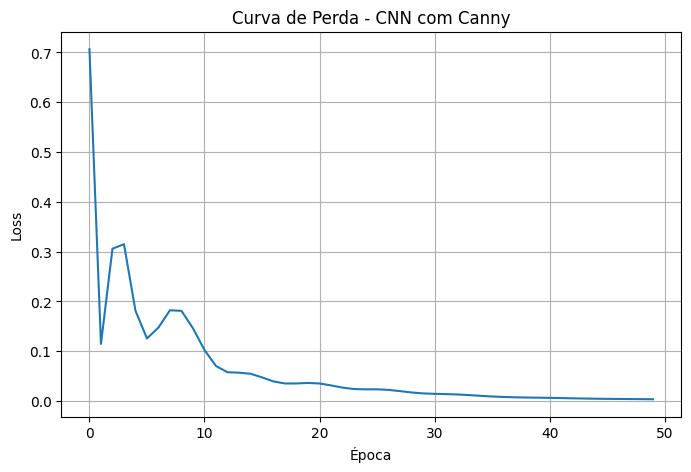

In [32]:
#Curva de perda
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Curva de Perda - CNN com Canny")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [33]:
# Avaliação final
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    preds = torch.argmax(outputs, dim=1)

accuracy = (preds == y_test).float().mean()

print("Acurácia:", accuracy.item())


Acurácia: 1.0


testar 3 versões: Grayscale, Canny, Grayscale + Canny concatenado como 2 canais

In [34]:
# Grayscale
X_gray = []

for img in imagens_64:
    tensor_img = torch.tensor(img, dtype=torch.float32)
    tensor_img = tensor_img.unsqueeze(0)  # 1 canal
    X_gray.append(tensor_img)

X_gray = torch.stack(X_gray)

In [35]:
# Canny
X_canny = []

for img in imagens_canny:
    tensor_img = torch.tensor(img, dtype=torch.float32)
    tensor_img = tensor_img.unsqueeze(0)  # 1 canal
    X_canny.append(tensor_img)

X_canny = torch.stack(X_canny)

In [36]:
# Grayscale + Canny (2 canais)
X_combined = []

for i in range(len(imagens_64)):
    tensor_gray = torch.tensor(imagens_64[i], dtype=torch.float32)
    tensor_canny = torch.tensor(imagens_canny[i], dtype=torch.float32)

    combined = torch.stack([tensor_gray, tensor_canny])  # 2 canais
    X_combined.append(combined)

X_combined = torch.stack(X_combined)

In [37]:
print("Gray:", X_gray.shape)
print("Canny:", X_canny.shape)
print("Combined:", X_combined.shape)

Gray: torch.Size([12, 1, 64, 64])
Canny: torch.Size([12, 1, 64, 64])
Combined: torch.Size([12, 2, 64, 64])


In [38]:
def train_and_evaluate(X, y, in_channels):

    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    class CNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(in_channels, 16, 3, padding=1)
            self.pool = nn.MaxPool2d(2,2)
            self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
            self.fc1 = nn.Linear(32*16*16, 32)
            self.fc2 = nn.Linear(32, 2)

        def forward(self,x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = x.view(x.size(0), -1)
            x = F.relu(self.fc1(x))
            return self.fc2(x)

    model = CNN()

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    epochs = 40
    loss_history = []

    for epoch in range(epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        preds = torch.argmax(outputs, dim=1)

    accuracy = (preds == y_test).float().mean().item()

    return accuracy, loss_history

In [39]:
acc_gray, loss_gray = train_and_evaluate(X_gray, y, 1)
acc_canny, loss_canny = train_and_evaluate(X_canny, y, 1)
acc_combined, loss_combined = train_and_evaluate(X_combined, y, 2)

print("Acurácia Gray:", acc_gray)
print("Acurácia Canny:", acc_canny)
print("Acurácia Combined:", acc_combined)

Acurácia Gray: 1.0
Acurácia Canny: 0.25
Acurácia Combined: 0.25


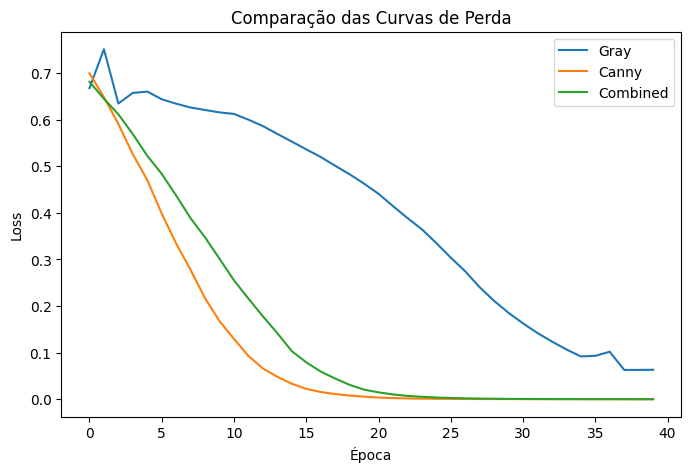

In [40]:
plt.figure(figsize=(8,5))
plt.plot(loss_gray, label="Gray")
plt.plot(loss_canny, label="Canny")
plt.plot(loss_combined, label="Combined")
plt.legend()
plt.title("Comparação das Curvas de Perda")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()